# 1. Carga de Datos y Limpieza
# 1.1 Carga del Dataset

## 1.2 Limpieza y Consistencia de los Datos



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#1 Carga de la base de datos
df = pd.read_csv('online_shoppers_intention.csv')
print("Datos Originales:")
print(f"Filas iniciales: {df.shape[0]} | Columnas: {df.shape[1]}")

#2 Limpieza de Duplicados
duplicados = df.duplicated().sum()
print(f"\nRegistros duplicados encontrados: {duplicados}")
if duplicados > 0:
    df = df.drop_duplicates()
    print(f"Filas actuales (sin duplicados): {df.shape[0]}")
    
#3 Control de Valores Nulos(Faltantes)
print("\nValores nulos por columna:")
print(df.isnull().sum())


Datos Originales:
Filas iniciales: 12330 | Columnas: 18

Registros duplicados encontrados: 125
Filas actuales (sin duplicados): 12205

Valores nulos por columna:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


# 2. Analisis de Datos (EDA)
## 2.1 Distribuicion de la Variable Objetivo 

Distribucion de Compras (Revenue)
Revenue
False    10297
True      1908
Name: count, dtype: int64

Porcentaje de Distribución de Compras (Revenue)
Revenue
False    84.367063
True     15.632937
Name: proportion, dtype: float64


C:\Users\Julian\AppData\Local\Temp\ipykernel_26636\2123056152.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Revenue', data=df, palette='Set2')


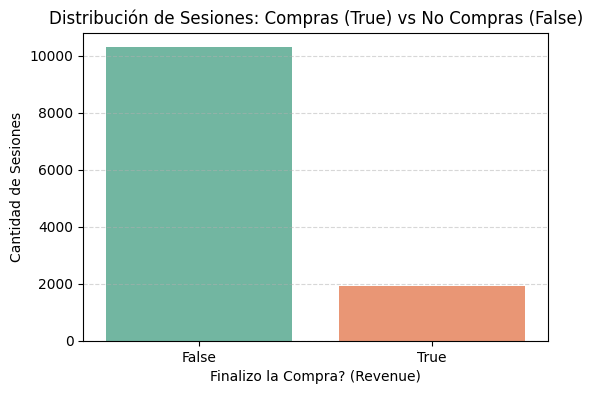

In [5]:
print("Distribucion de Compras (Revenue)")
print (df['Revenue'].value_counts())

print("\nPorcentaje de Distribución de Compras (Revenue)")
print(df['Revenue'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='Revenue', data=df, palette='Set2')
plt.title('Distribución de Sesiones: Compras (True) vs No Compras (False)')
plt.xlabel('Finalizo la Compra? (Revenue)')
plt.ylabel('Cantidad de Sesiones')
plt.grid(axis='y', linestyle='--', alpha=0.5)

## 2.2 Relacion entre el Valor de la Pagina  y las Compras

C:\Users\Julian\AppData\Local\Temp\ipykernel_26636\4031816482.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Revenue', y='PageValues', data=df, palette='Pastel1')


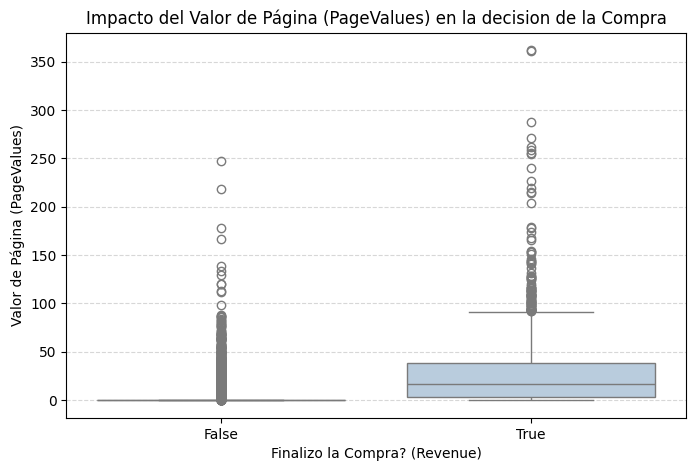

---Promedio de PageValues segun la compra---
Revenue
False     1.999985
True     27.264518
Name: PageValues, dtype: float64


In [6]:
plt.figure(figsize=(8, 5))

#Graficamos la relación entre el valor de página (PageValues) y la decisión de compra (Revenue)
sns.boxplot(x='Revenue', y='PageValues', data=df, palette='Pastel1')

plt.title('Impacto del Valor de Página (PageValues) en la decision de la Compra')
plt.xlabel('Finalizo la Compra? (Revenue)')
plt.ylabel('Valor de Página (PageValues)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

#Calculamos el promedio numerico para el informe escrito 
print("---Promedio de PageValues segun la compra---")
print(df.groupby('Revenue')['PageValues'].mean())



# 2.3 Impacto del tipo de visitante (VisitorType) en la compras

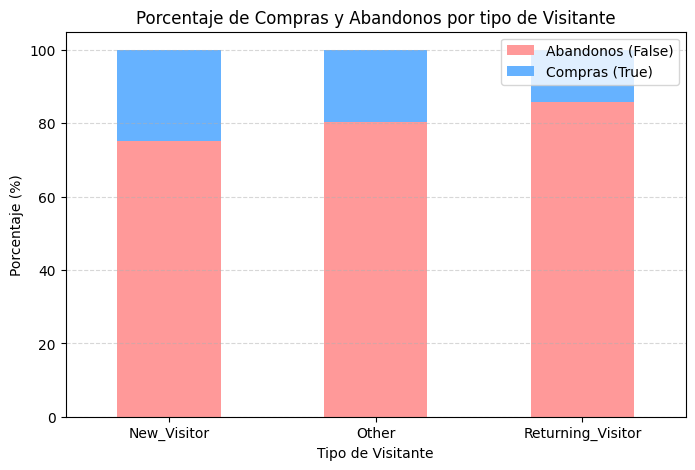

---Porcentajes Exactos de Conversion por tipo de Visitante---
Revenue                False      True 
VisitorType                            
New_Visitor        75.073833  24.926167
Other              80.246914  19.753086
Returning_Visitor  85.907391  14.092609


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creamos una tabla cruzada en porcentajes 
tabla_visitantes = pd.crosstab(df['VisitorType'], df['Revenue'], normalize='index') * 100

# Graficamos la tabla cruzada en un gráfico de barras

tabla_visitantes.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#FF9999', '#66B2FF'])
plt.title('Porcentaje de Compras y Abandonos por tipo de Visitante')
plt.xlabel('Tipo de Visitante')
plt.ylabel('Porcentaje (%)') 
plt.legend(['Abandonos (False)', 'Compras (True)'], loc='upper right')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print("---Porcentajes Exactos de Conversion por tipo de Visitante---")
print(tabla_visitantes)

## 2.4 Relacion entre la Tasa de Salida (ExitRates) y las Compras

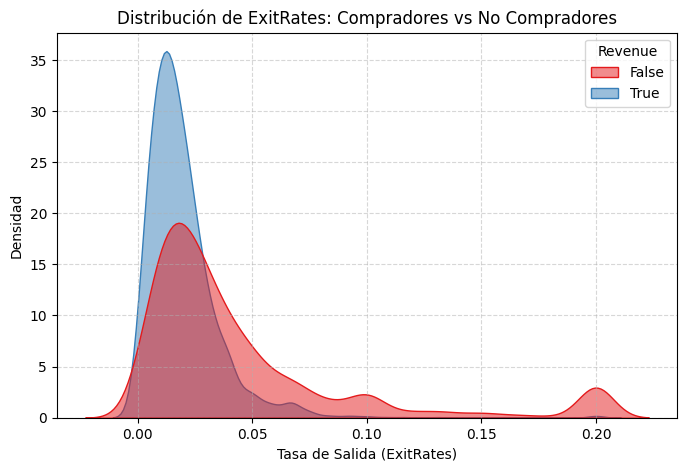

In [8]:
plt.figure(figsize=(8, 5))

# Graficas la curva de distribucion de ExitRates para compradores vs nocompradores
sns.kdeplot(data=df, x='ExitRates', hue='Revenue', fill=True, common_norm=False, palette='Set1', alpha=0.5)
plt.title('Distribución de ExitRates: Compradores vs No Compradores')
plt.xlabel('Tasa de Salida (ExitRates)')
plt.ylabel('Densidad')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 3. Preprocesamiento de Datos
## 3.1 Conversion de Variables Categoricas a Numericas (Encoding)

In [9]:
columnas_texto = df.select_dtypes(include=['object']).columns.tolist()
print(f"Variables de texto encontradas: {columnas_texto}")

df_procesado = pd.get_dummies(df, columns=columnas_texto, drop_first=True)

df_procesado['Weekend'] = df_procesado['Weekend'].astype(int) 
df_procesado['Revenue'] = df_procesado['Revenue'].astype(int)

print("\n---Dataset transformado con exito---")
print(f"Nuevas dimensiones del dataset: {df_procesado.shape}")
df_procesado.head(3)

Variables de texto encontradas: ['Month', 'VisitorType']

---Dataset transformado con exito---
Nuevas dimensiones del dataset: (12205, 27)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.0,0.0,0.1,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True


# 4. Modelado Predictivo 
## 4.1 Entrenamiento y Evaluacion del Modelo de Scoring 

--- REPORTE DE CLASIFICACION ---
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2079
           1       0.75      0.51      0.60       362

    accuracy                           0.90      2441
   macro avg       0.83      0.74      0.77      2441
weighted avg       0.89      0.90      0.89      2441

Metrica ROC-AUC Score: 0.9244


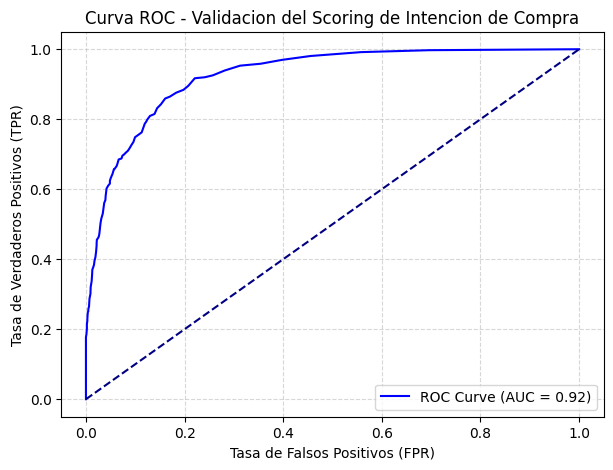

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

x = df_procesado.drop(columns=['Revenue'])
y = df_procesado['Revenue']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

modelo_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
modelo_rf.fit(X_train, y_train)

y_pred = modelo_rf.predict(X_test)
y_probs = modelo_rf.predict_proba(X_test)[:, 1]

print("--- REPORTE DE CLASIFICACION ---")
print(classification_report(y_test, y_pred))

auc_score = roc_auc_score(y_test, y_probs)
print(f"Metrica ROC-AUC Score: {auc_score:.4f}")

fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('Curva ROC - Validacion del Scoring de Intencion de Compra')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()